In [10]:
import pandas as pd
import numpy as np
import ast
import re

In [11]:
df = pd.read_excel("../data/bangalore_cars.xlsx")

df.head()

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...
3,"{'it': 0, 'ft': 'Petrol', 'bt': 'Sedan', 'km':...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...
4,"{'it': 0, 'ft': 'Diesel', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...


In [12]:
print(df.loc[0, "new_car_detail"])

{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', 'km': '1,20,000', 'transmission': 'Manual', 'ownerNo': 3, 'owner': '3rd Owner', 'oem': 'Maruti', 'model': 'Maruti Celerio', 'modelYear': 2015, 'centralVariantId': 3979, 'variantName': 'VXI', 'price': '₹ 4 Lakh', 'priceActual': '', 'priceSaving': '', 'priceFixedText': None, 'trendingText': {'imgUrl': 'https://stimg.cardekho.com/used-cars/common/icons/trending.svg', 'heading': 'Trending Car!', 'desc': 'High chances of sale in next 6 days'}}


In [13]:
print(type(df.loc[0, "new_car_detail"]))

<class 'str'>


In [14]:
sample_detail = df.loc[0, "new_car_detail"]
detail_dict = ast.literal_eval(sample_detail)

detail_dict

{'it': 0,
 'ft': 'Petrol',
 'bt': 'Hatchback',
 'km': '1,20,000',
 'transmission': 'Manual',
 'ownerNo': 3,
 'owner': '3rd Owner',
 'oem': 'Maruti',
 'model': 'Maruti Celerio',
 'modelYear': 2015,
 'centralVariantId': 3979,
 'variantName': 'VXI',
 'price': '₹ 4 Lakh',
 'priceActual': '',
 'priceSaving': '',
 'priceFixedText': None,
 'trendingText': {'imgUrl': 'https://stimg.cardekho.com/used-cars/common/icons/trending.svg',
  'heading': 'Trending Car!',
  'desc': 'High chances of sale in next 6 days'}}

In [15]:
print("Fuel type:", detail_dict.get("ft"))
print("Body type:", detail_dict.get("bt"))
print("KM driven:", detail_dict.get("km"))
print("Transmission:", detail_dict.get("transmission"))
print("Owner no:", detail_dict.get("ownerNo"))
print("Brand:", detail_dict.get("oem"))
print("Model:", detail_dict.get("model"))
print("Year:", detail_dict.get("modelYear"))
print("Variant:", detail_dict.get("variantName"))
print("Price:", detail_dict.get("price"))

Fuel type: Petrol
Body type: Hatchback
KM driven: 1,20,000
Transmission: Manual
Owner no: 3
Brand: Maruti
Model: Maruti Celerio
Year: 2015
Variant: VXI
Price: ₹ 4 Lakh


In [16]:
def extract_car_detail(detail_text):
    try:
        d = ast.literal_eval(detail_text) if isinstance(detail_text, str) else detail_text
        
        return {
            "fuel_type": d.get("ft"),
            "body_type": d.get("bt"),
            "km_driven": d.get("km"),
            "transmission": d.get("transmission"),
            "owner_no": d.get("ownerNo"),
            "brand": d.get("oem"),
            "model": d.get("model"),
            "model_year": d.get("modelYear"),
            "variant": d.get("variantName"),
            "price": d.get("price")
        }
    except:
        return {
            "fuel_type": None,
            "body_type": None,
            "km_driven": None,
            "transmission": None,
            "owner_no": None,
            "brand": None,
            "model": None,
            "model_year": None,
            "variant": None,
            "price": None
        }

In [17]:
detail_extracted = df["new_car_detail"].apply(extract_car_detail)

detail_df = pd.DataFrame(detail_extracted.tolist())

detail_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price
0,Petrol,Hatchback,"1,20,000",Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh
1,Petrol,SUV,"32,706",Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh
2,Petrol,Hatchback,"11,949",Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh
3,Petrol,Sedan,"17,794",Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh
4,Diesel,SUV,"60,000",Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh


In [18]:
detail_df["city"] = "Bangalore"

In [19]:
detail_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,city
0,Petrol,Hatchback,"1,20,000",Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh,Bangalore
1,Petrol,SUV,"32,706",Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,Bangalore
2,Petrol,Hatchback,"11,949",Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh,Bangalore
3,Petrol,Sedan,"17,794",Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh,Bangalore
4,Diesel,SUV,"60,000",Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh,Bangalore


In [20]:
def extract_car_detail(detail_text):
    try:
        d = ast.literal_eval(detail_text) if isinstance(detail_text, str) else detail_text

        return {
            "fuel_type": d.get("ft"),
            "body_type": d.get("bt"),
            "km_driven": d.get("km"),
            "transmission": d.get("transmission"),
            "owner_no": d.get("ownerNo"),
            "brand": d.get("oem"),
            "model": d.get("model"),
            "model_year": d.get("modelYear"),
            "variant": d.get("variantName"),
            "price": d.get("price")
        }
    except:
        return {
            "fuel_type": None,
            "body_type": None,
            "km_driven": None,
            "transmission": None,
            "owner_no": None,
            "brand": None,
            "model": None,
            "model_year": None,
            "variant": None,
            "price": None
        }

In [21]:
detail_extracted = df["new_car_detail"].apply(extract_car_detail)
detail_df = pd.DataFrame(detail_extracted.tolist())
detail_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price
0,Petrol,Hatchback,"1,20,000",Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh
1,Petrol,SUV,"32,706",Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh
2,Petrol,Hatchback,"11,949",Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh
3,Petrol,Sedan,"17,794",Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh
4,Diesel,SUV,"60,000",Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh


In [22]:
detail_df["city"] = "Bangalore"
detail_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,city
0,Petrol,Hatchback,"1,20,000",Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh,Bangalore
1,Petrol,SUV,"32,706",Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,Bangalore
2,Petrol,Hatchback,"11,949",Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh,Bangalore
3,Petrol,Sedan,"17,794",Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh,Bangalore
4,Diesel,SUV,"60,000",Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh,Bangalore


In [23]:
print(detail_df.shape)
print(detail_df.isnull().sum())

(1481, 11)
fuel_type       0
body_type       0
km_driven       0
transmission    0
owner_no        0
brand           0
model           0
model_year      0
variant         0
price           0
city            0
dtype: int64


In [24]:
def clean_km(x):
    try:
        if pd.isna(x):
            return None
        x = str(x).replace(",", "").strip()
        return int(re.findall(r"\d+", x)[0])
    except:
        return None


def clean_price(x):
    try:
        if pd.isna(x):
            return None
        
        x = str(x).replace("₹", "").replace(",", "").strip().lower()
        
        if "lakh" in x:
            num = float(re.findall(r"\d+\.?\d*", x)[0])
            return int(num * 100000)
        elif "crore" in x:
            num = float(re.findall(r"\d+\.?\d*", x)[0])
            return int(num * 10000000)
        else:
            num = float(re.findall(r"\d+\.?\d*", x)[0])
            return int(num)
    except:
        return None

In [25]:
detail_df["km_driven"] = detail_df["km_driven"].apply(clean_km)
detail_df["price"] = detail_df["price"].apply(clean_price)

detail_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,city
0,Petrol,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,400000,Bangalore
1,Petrol,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,811000,Bangalore
2,Petrol,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,585000,Bangalore
3,Petrol,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,462000,Bangalore
4,Diesel,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,790000,Bangalore


In [26]:
detail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fuel_type     1481 non-null   object
 1   body_type     1481 non-null   object
 2   km_driven     1481 non-null   int64 
 3   transmission  1481 non-null   object
 4   owner_no      1481 non-null   int64 
 5   brand         1481 non-null   object
 6   model         1481 non-null   object
 7   model_year    1481 non-null   int64 
 8   variant       1481 non-null   object
 9   price         1481 non-null   int64 
 10  city          1481 non-null   object
dtypes: int64(4), object(7)
memory usage: 127.4+ KB


In [27]:
print(df.loc[0, "new_car_overview"])
print(type(df.loc[0, "new_car_overview"]))

{'heading': 'Car overview', 'top': [{'key': 'Registration Year', 'value': '2015', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/registrationYear.svg'}, {'key': 'Insurance Validity', 'value': 'Third Party insurance', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/insuranceValidity.svg'}, {'key': 'Fuel Type', 'value': 'Petrol', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/fuel.svg'}, {'key': 'Seats', 'value': '5 Seats', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/seats.svg'}, {'key': 'Kms Driven', 'value': '1,20,000 Kms', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/kmsDriven.svg'}, {'key': 'RTO', 'value': 'KA51', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/rto.svg'}, {'key': 'Ownership', 'value': 'Third Owner', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/ownership.svg'}, {'key': 'Engine Displacement', 'value': '998 cc', 'icon': 'https://images10.gaadi.com/listing/vdp/co/v1/engineDisplacement.svg'}, {'key': 'Transmission', 'v

In [28]:
print(df.loc[0, "new_car_specs"])
print(type(df.loc[0, "new_car_specs"]))

{'heading': 'Specifications', 'top': [{'key': 'Mileage', 'value': '23.1 kmpl'}, {'key': 'Engine', 'value': '998 CC'}, {'key': 'Max Power', 'value': '67.04bhp'}, {'key': 'Torque', 'value': '90Nm'}, {'key': 'Seats', 'value': '5'}], 'data': [{'heading': 'Engine and Transmission', 'subHeading': 'Engine', 'list': [{'key': 'Color', 'value': 'White'}, {'key': 'Engine Type', 'value': 'K10B Engine'}, {'key': 'Displacement', 'value': '998'}, {'key': 'Max Power', 'value': '67.04bhp@6000rpm'}, {'key': 'Max Torque', 'value': '90Nm@3500rpm'}, {'key': 'No of Cylinder', 'value': 3}, {'key': 'Values per Cylinder', 'value': 4}, {'key': 'Value Configuration', 'value': 'DOHC'}, {'key': 'Fuel Suppy System', 'value': 'MPFi'}, {'key': 'BoreX Stroke', 'value': '73 X 82 mm'}, {'key': 'Compression Ratio', 'value': '11.0:1'}, {'key': 'Turbo Charger', 'value': 'No'}, {'key': 'Super Charger', 'value': 'No'}]}, {'heading': 'Dimensions & Capacity', 'subHeading': 'Dimensions', 'list': [{'key': 'Length', 'value': '371

In [29]:
def extract_overview(overview_text):
    try:
        d = ast.literal_eval(overview_text) if isinstance(overview_text, str) else overview_text
        
        result = {
            "registration_year": None,
            "insurance_validity": None,
            "fuel_overview": None,
            "seats_overview": None,
            "ownership_overview": None
        }
        
        top_data = d.get("top", [])
        
        for item in top_data:
            key = item.get("key", "").strip().lower()
            value = item.get("value", "")
            
            if key == "registration year":
                result["registration_year"] = value
            elif key == "insurance validity":
                result["insurance_validity"] = value
            elif key == "fuel type":
                result["fuel_overview"] = value
            elif key == "seats":
                result["seats_overview"] = value
            elif key == "ownership":
                result["ownership_overview"] = value
                
        return result
    except:
        return {
            "registration_year": None,
            "insurance_validity": None,
            "fuel_overview": None,
            "seats_overview": None,
            "ownership_overview": None
        }

In [30]:
overview_extracted = df["new_car_overview"].apply(extract_overview)
overview_df = pd.DataFrame(overview_extracted.tolist())

overview_df.head()

,registration_year,insurance_validity,fuel_overview,seats_overview,ownership_overview
0,2015,Third Party insurance,Petrol,5 Seats,Third Owner
1,Feb 2018,Comprehensive,Petrol,5 Seats,Second Owner
2,Sept 2018,Comprehensive,Petrol,5 Seats,First Owner
3,Dec 2014,Comprehensive,Petrol,5 Seats,First Owner
4,2015,Third Party insurance,Diesel,5 Seats,First Owner


In [31]:
def extract_specs(specs_text):
    try:
        d = ast.literal_eval(specs_text) if isinstance(specs_text, str) else specs_text
        
        result = {
            "mileage": None,
            "engine": None,
            "max_power": None,
            "torque": None,
            "seats_specs": None
        }
        
        top_data = d.get("top", [])
        
        for item in top_data:
            key = item.get("key", "").strip().lower()
            value = item.get("value", "")
            
            if key == "mileage":
                result["mileage"] = value
            elif key == "engine":
                result["engine"] = value
            elif key == "max power":
                result["max_power"] = value
            elif key == "torque":
                result["torque"] = value
            elif key == "seats":
                result["seats_specs"] = value
                
        return result
    except:
        return {
            "mileage": None,
            "engine": None,
            "max_power": None,
            "torque": None,
            "seats_specs": None
        }

In [32]:
specs_extracted = df["new_car_specs"].apply(extract_specs)
specs_df = pd.DataFrame(specs_extracted.tolist())

specs_df.head()

,mileage,engine,max_power,torque,seats_specs
0,23.1 kmpl,998 CC,67.04bhp,90Nm,5
1,17 kmpl,1497 CC,121.31bhp,150Nm,5
2,23.84 kmpl,1199 CC,84bhp,114Nm,5
3,19.1 kmpl,1197 CC,81.86bhp,113.75Nm,5
4,23.65 kmpl,1248 CC,88.5bhp,200Nm,5


In [33]:
bangalore_df = pd.concat([detail_df, overview_df, specs_df], axis=1)

bangalore_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,...,registration_year,insurance_validity,fuel_overview,seats_overview,ownership_overview,mileage,engine,max_power,torque,seats_specs
0,Petrol,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,400000,...,2015,Third Party insurance,Petrol,5 Seats,Third Owner,23.1 kmpl,998 CC,67.04bhp,90Nm,5
1,Petrol,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,811000,...,Feb 2018,Comprehensive,Petrol,5 Seats,Second Owner,17 kmpl,1497 CC,121.31bhp,150Nm,5
2,Petrol,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,585000,...,Sept 2018,Comprehensive,Petrol,5 Seats,First Owner,23.84 kmpl,1199 CC,84bhp,114Nm,5
3,Petrol,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,462000,...,Dec 2014,Comprehensive,Petrol,5 Seats,First Owner,19.1 kmpl,1197 CC,81.86bhp,113.75Nm,5
4,Diesel,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,790000,...,2015,Third Party insurance,Diesel,5 Seats,First Owner,23.65 kmpl,1248 CC,88.5bhp,200Nm,5


In [34]:
print(bangalore_df.shape)
print(bangalore_df.isnull().sum())

(1481, 21)
fuel_type              0
body_type              0
km_driven              0
transmission           0
owner_no               0
brand                  0
model                  0
model_year             0
variant                0
price                  0
city                   0
registration_year      7
insurance_validity     3
fuel_overview          0
seats_overview         1
ownership_overview     0
mileage               42
engine                 3
max_power             16
torque                16
seats_specs            1
dtype: int64


In [35]:
def extract_number(x):
    try:
        if pd.isna(x):
            return None
        match = re.findall(r"\d+\.?\d*", str(x).replace(",", ""))
        return float(match[0]) if match else None
    except:
        return None

In [36]:
bangalore_df["registration_year"] = bangalore_df["registration_year"].apply(extract_number)
bangalore_df["seats_overview"] = bangalore_df["seats_overview"].apply(extract_number)
bangalore_df["mileage"] = bangalore_df["mileage"].apply(extract_number)
bangalore_df["engine"] = bangalore_df["engine"].apply(extract_number)
bangalore_df["max_power"] = bangalore_df["max_power"].apply(extract_number)
bangalore_df["torque"] = bangalore_df["torque"].apply(extract_number)
bangalore_df["seats_specs"] = bangalore_df["seats_specs"].apply(extract_number)

In [37]:
bangalore_df[[
    "registration_year",
    "seats_overview",
    "mileage",
    "engine",
    "max_power",
    "torque",
    "seats_specs"
]].head(10)

,registration_year,seats_overview,mileage,engine,max_power,torque,seats_specs
0,2015.0,5.0,23.10,998.0,67.04,90.00,5.0
1,2018.0,5.0,17.00,1497.0,121.31,150.00,5.0
2,2018.0,5.0,23.84,1199.0,84.00,114.00,5.0
3,2014.0,5.0,19.10,1197.0,81.86,113.75,5.0
4,2015.0,5.0,23.65,1248.0,88.50,200.00,5.0
5,2020.0,5.0,17.10,1956.0,170.00,350.00,5.0
6,2017.0,5.0,20.63,1198.0,67.00,104.00,5.0
7,2021.0,5.0,18.15,998.0,118.35,171.60,5.0
8,2018.0,5.0,20.28,1462.0,103.25,138.00,5.0
9,2018.0,5.0,23.84,1199.0,84.00,114.00,5.0


In [38]:
bangalore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fuel_type           1481 non-null   object 
 1   body_type           1481 non-null   object 
 2   km_driven           1481 non-null   int64  
 3   transmission        1481 non-null   object 
 4   owner_no            1481 non-null   int64  
 5   brand               1481 non-null   object 
 6   model               1481 non-null   object 
 7   model_year          1481 non-null   int64  
 8   variant             1481 non-null   object 
 9   price               1481 non-null   int64  
 10  city                1481 non-null   object 
 11  registration_year   1474 non-null   float64
 12  insurance_validity  1478 non-null   object 
 13  fuel_overview       1481 non-null   object 
 14  seats_overview      1480 non-null   float64
 15  ownership_overview  1481 non-null   object 
 16  mileag

In [39]:
bangalore_df["seats"] = bangalore_df["seats_overview"].fillna(bangalore_df["seats_specs"])

In [40]:
bangalore_df.isnull().sum()

fuel_type              0
body_type              0
km_driven              0
transmission           0
owner_no               0
brand                  0
model                  0
model_year             0
variant                0
price                  0
city                   0
registration_year      7
insurance_validity     3
fuel_overview          0
seats_overview         1
ownership_overview     0
mileage               42
engine                 3
max_power             16
torque                16
seats_specs            1
seats                  1
dtype: int64

In [41]:
numeric_cols = [
    "registration_year", "mileage", "engine",
    "max_power", "torque", "seats"
]

for col in numeric_cols:
    bangalore_df[col] = bangalore_df[col].fillna(bangalore_df[col].median())

In [42]:
categorical_cols = ["insurance_validity"]

for col in categorical_cols:
    bangalore_df[col] = bangalore_df[col].fillna(bangalore_df[col].mode()[0])

In [43]:
bangalore_df.isnull().sum()

fuel_type             0
body_type             0
km_driven             0
transmission          0
owner_no              0
brand                 0
model                 0
model_year            0
variant               0
price                 0
city                  0
registration_year     0
insurance_validity    0
fuel_overview         0
seats_overview        1
ownership_overview    0
mileage               0
engine                0
max_power             0
torque                0
seats_specs           1
seats                 0
dtype: int64

In [44]:
bangalore_df.drop(columns=["fuel_overview", "seats_overview", "seats_specs"], inplace=True)

In [45]:
bangalore_df.to_csv("../output/bangalore_cleaned.csv", index=False)

In [46]:
def process_city(file_path, city_name):
    
    df = pd.read_excel(file_path)
    
    # -------- Extract detail --------
    detail_extracted = df["new_car_detail"].apply(extract_car_detail)
    detail_df = pd.DataFrame(detail_extracted.tolist())
    
    # -------- Extract overview --------
    overview_extracted = df["new_car_overview"].apply(extract_overview)
    overview_df = pd.DataFrame(overview_extracted.tolist())
    
    # -------- Extract specs --------
    specs_extracted = df["new_car_specs"].apply(extract_specs)
    specs_df = pd.DataFrame(specs_extracted.tolist())
    
    # -------- Combine --------
    city_df = pd.concat([detail_df, overview_df, specs_df], axis=1)
    
    # -------- Add city --------
    city_df["city"] = city_name
    
    # -------- Clean km & price --------
    city_df["km_driven"] = city_df["km_driven"].apply(clean_km)
    city_df["price"] = city_df["price"].apply(clean_price)
    
    # -------- Extract numbers --------
    for col in ["registration_year", "seats_overview", "mileage", "engine", "max_power", "torque", "seats_specs"]:
        city_df[col] = city_df[col].apply(extract_number)
    
    # -------- Combine seats --------
    city_df["seats"] = city_df["seats_overview"].fillna(city_df["seats_specs"])
    
    # -------- Handle missing --------
    numeric_cols = ["registration_year", "mileage", "engine", "max_power", "torque", "seats"]
    
    for col in numeric_cols:
        city_df[col] = city_df[col].fillna(city_df[col].median())
    
    city_df["insurance_validity"] = city_df["insurance_validity"].fillna(city_df["insurance_validity"].mode()[0])
    
    # -------- Drop unwanted --------
    city_df.drop(columns=["fuel_overview", "seats_overview", "seats_specs"], inplace=True)
    
    return city_df

In [47]:
chennai_df = process_city("../data/chennai_cars.xlsx", "Chennai")

chennai_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,registration_year,insurance_validity,ownership_overview,mileage,engine,max_power,torque,city,seats
0,Petrol,SUV,20000,Automatic,1,Kia,Kia Sonet,2022,Turbo DCT Anniversary Edition,1150000,2022.0,Third Party insurance,First Owner,18.90,998.0,118.36,172.00,Chennai,5.0
1,Petrol,Minivans,20687,Manual,1,Maruti,Maruti Eeco,2015,7 Seater Standard BSIV,415000,2015.0,Comprehensive,First Owner,15.37,1196.0,73.00,101.00,Chennai,7.0
2,Petrol,SUV,30000,Manual,1,Nissan,Nissan Magnite,2021,Turbo XV Premium BSVI,750000,2021.0,Third Party insurance,First Owner,20.00,999.0,98.63,160.00,Chennai,5.0
3,Petrol,Hatchback,59247,Manual,1,Hyundai,Hyundai i10,2015,Sportz 1.1L,398000,2015.0,Comprehensive,First Owner,19.81,1086.0,68.05,99.04,Chennai,5.0
4,Petrol,Hatchback,50000,Manual,1,Honda,Honda Jazz,2015,1.2 VX i VTEC,550000,2015.0,Third Party insurance,First Owner,18.70,1199.0,88.70,110.00,Chennai,5.0


In [48]:
print(chennai_df.shape)
print(chennai_df.isnull().sum())

(1419, 19)
fuel_type              0
body_type              0
km_driven              0
transmission           0
owner_no               0
brand                  0
model                  0
model_year             0
variant                0
price                  0
registration_year      0
insurance_validity     0
ownership_overview    22
mileage                0
engine                 0
max_power              0
torque                 0
city                   0
seats                  0
dtype: int64


In [49]:
bangalore_df = process_city("../data/bangalore_cars.xlsx", "Bangalore")
chennai_df = process_city("../data/chennai_cars.xlsx", "Chennai")
delhi_df = process_city("../data/delhi_cars.xlsx", "Delhi")
hyderabad_df = process_city("../data/hyderabad_cars.xlsx", "Hyderabad")
jaipur_df = process_city("../data/jaipur_cars.xlsx", "Jaipur")
kolkata_df = process_city("../data/kolkata_cars.xlsx", "Kolkata")

In [50]:
final_df = pd.concat([
    bangalore_df,
    chennai_df,
    delhi_df,
    hyderabad_df,
    jaipur_df,
    kolkata_df
], ignore_index=True)

final_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,registration_year,insurance_validity,ownership_overview,mileage,engine,max_power,torque,city,seats
0,Petrol,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,400000,2015.0,Third Party insurance,Third Owner,23.10,998.0,67.04,90.00,Bangalore,5.0
1,Petrol,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,811000,2018.0,Comprehensive,Second Owner,17.00,1497.0,121.31,150.00,Bangalore,5.0
2,Petrol,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,585000,2018.0,Comprehensive,First Owner,23.84,1199.0,84.00,114.00,Bangalore,5.0
3,Petrol,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,462000,2014.0,Comprehensive,First Owner,19.10,1197.0,81.86,113.75,Bangalore,5.0
4,Diesel,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,790000,2015.0,Third Party insurance,First Owner,23.65,1248.0,88.50,200.00,Bangalore,5.0


In [51]:
print(final_df.shape)
print(final_df["city"].value_counts())

(8369, 19)
city
Delhi        1485
Hyderabad    1483
Bangalore    1481
Chennai      1419
Kolkata      1381
Jaipur       1120
Name: count, dtype: int64


In [52]:
final_df.to_csv("../output/final_cleaned_data.csv", index=False)

In [53]:
final_df.describe(include="all")

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,registration_year,insurance_validity,ownership_overview,mileage,engine,max_power,torque,city,seats
count,8369,8369,8.369000e+03,8369,8369.000000,8369,8369,8369.000000,8369,8.369000e+03,8369.000000,8369,8337,8369.000000,8369.000000,8369.000000,8369.000000,8369,8369.000000
unique,5,11,NaN,2,NaN,33,315,NaN,2157,NaN,NaN,7,5,NaN,NaN,NaN,NaN,6,NaN
top,Petrol,Hatchback,NaN,Manual,NaN,Maruti,Honda City,NaN,VXI,NaN,NaN,Third Party insurance,First Owner,NaN,NaN,NaN,NaN,Delhi,NaN
freq,5554,3567,NaN,6052,NaN,2252,370,NaN,337,NaN,NaN,4058,5882,NaN,NaN,NaN,NaN,1485,NaN
mean,NaN,NaN,5.897430e+04,NaN,1.360139,NaN,NaN,2016.503286,NaN,9.569036e+05,2016.614052,NaN,NaN,19.247179,1424.645597,105.083365,177.547350,NaN,5.203131
std,NaN,NaN,7.406100e+04,NaN,0.641958,NaN,NaN,3.921465,NaN,1.416203e+06,3.801218,NaN,NaN,3.961902,477.533067,46.253656,109.513637,NaN,0.663573
min,NaN,NaN,0.000000e+00,NaN,0.000000,NaN,NaN,1985.000000,NaN,2.016100e+04,2002.000000,NaN,NaN,7.080000,0.000000,25.400000,4.800000,NaN,2.000000
25%,NaN,NaN,3.000000e+04,NaN,1.000000,NaN,NaN,2014.000000,NaN,3.990000e+05,2014.000000,NaN,NaN,17.010000,1197.000000,78.900000,110.000000,NaN,5.000000
50%,NaN,NaN,5.369200e+04,NaN,1.000000,NaN,NaN,2017.000000,NaN,6.010000e+05,2017.000000,NaN,NaN,18.900000,1248.000000,88.700000,140.000000,NaN,5.000000
75%,NaN,NaN,8.000000e+04,NaN,2.000000,NaN,NaN,2019.000000,NaN,9.500000e+05,2019.000000,NaN,NaN,21.400000,1498.000000,118.360000,215.000000,NaN,5.000000


In [54]:
final_df["price"].describe()

count    8.369000e+03
mean     9.569036e+05
std      1.416203e+06
min      2.016100e+04
25%      3.990000e+05
50%      6.010000e+05
75%      9.500000e+05
max      4.150000e+07
Name: price, dtype: float64

In [55]:
final_df["brand"].value_counts().head(10)

brand
Maruti           2252
Hyundai          1651
Honda             865
Tata              431
Mahindra          377
Toyota            325
Renault           312
Ford              311
Volkswagen        294
Mercedes-Benz     245
Name: count, dtype: int64

In [56]:
final_df["fuel_type"].value_counts()

fuel_type
Petrol      5554
Diesel      2673
Cng           98
Electric      28
Lpg           16
Name: count, dtype: int64

In [57]:
final_df["transmission"].value_counts()

transmission
Manual       6052
Automatic    2317
Name: count, dtype: int64

In [58]:
final_df["city"].value_counts()

city
Delhi        1485
Hyderabad    1483
Bangalore    1481
Chennai      1419
Kolkata      1381
Jaipur       1120
Name: count, dtype: int64

In [59]:
final_df.head()

,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,registration_year,insurance_validity,ownership_overview,mileage,engine,max_power,torque,city,seats
0,Petrol,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,400000,2015.0,Third Party insurance,Third Owner,23.10,998.0,67.04,90.00,Bangalore,5.0
1,Petrol,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,811000,2018.0,Comprehensive,Second Owner,17.00,1497.0,121.31,150.00,Bangalore,5.0
2,Petrol,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,585000,2018.0,Comprehensive,First Owner,23.84,1199.0,84.00,114.00,Bangalore,5.0
3,Petrol,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,462000,2014.0,Comprehensive,First Owner,19.10,1197.0,81.86,113.75,Bangalore,5.0
4,Diesel,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,790000,2015.0,Third Party insurance,First Owner,23.65,1248.0,88.50,200.00,Bangalore,5.0


In [60]:
final_df.shape

(8369, 19)

In [61]:
final_df.columns

Index(['fuel_type', 'body_type', 'km_driven', 'transmission', 'owner_no',
       'brand', 'model', 'model_year', 'variant', 'price', 'registration_year',
       'insurance_validity', 'ownership_overview', 'mileage', 'engine',
       'max_power', 'torque', 'city', 'seats'],
      dtype='object')

In [62]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fuel_type           8369 non-null   object 
 1   body_type           8369 non-null   object 
 2   km_driven           8369 non-null   int64  
 3   transmission        8369 non-null   object 
 4   owner_no            8369 non-null   int64  
 5   brand               8369 non-null   object 
 6   model               8369 non-null   object 
 7   model_year          8369 non-null   int64  
 8   variant             8369 non-null   object 
 9   price               8369 non-null   int64  
 10  registration_year   8369 non-null   float64
 11  insurance_validity  8369 non-null   object 
 12  ownership_overview  8337 non-null   object 
 13  mileage             8369 non-null   float64
 14  engine              8369 non-null   float64
 15  max_power           8369 non-null   float64
 16  torque

In [63]:
final_df.describe()

,km_driven,owner_no,model_year,price,registration_year,mileage,engine,max_power,torque,seats
count,8.369000e+03,8369.000000,8369.000000,8.369000e+03,8369.000000,8369.000000,8369.000000,8369.000000,8369.000000,8369.000000
mean,5.897430e+04,1.360139,2016.503286,9.569036e+05,2016.614052,19.247179,1424.645597,105.083365,177.547350,5.203131
std,7.406100e+04,0.641958,3.921465,1.416203e+06,3.801218,3.961902,477.533067,46.253656,109.513637,0.663573
min,0.000000e+00,0.000000,1985.000000,2.016100e+04,2002.000000,7.080000,0.000000,25.400000,4.800000,2.000000
25%,3.000000e+04,1.000000,2014.000000,3.990000e+05,2014.000000,17.010000,1197.000000,78.900000,110.000000,5.000000
50%,5.369200e+04,1.000000,2017.000000,6.010000e+05,2017.000000,18.900000,1248.000000,88.700000,140.000000,5.000000
75%,8.000000e+04,2.000000,2019.000000,9.500000e+05,2019.000000,21.400000,1498.000000,118.360000,215.000000,5.000000
max,5.500000e+06,5.000000,2023.000000,4.150000e+07,2023.000000,140.000000,5000.000000,576.630000,850.000000,10.000000


In [64]:
final_df.isnull().sum()

fuel_type              0
body_type              0
km_driven              0
transmission           0
owner_no               0
brand                  0
model                  0
model_year             0
variant                0
price                  0
registration_year      0
insurance_validity     0
ownership_overview    32
mileage                0
engine                 0
max_power              0
torque                 0
city                   0
seats                  0
dtype: int64

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
import pandas as pd

In [69]:
print(bangalore_df.shape)

(1481, 19)


In [70]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
bangalore_df = process_city("../data/bangalore_cars.xlsx", "Bangalore")
chennai_df = process_city("../data/chennai_cars.xlsx", "Chennai")
delhi_df = process_city("../data/delhi_cars.xlsx", "Delhi")
hyderabad_df = process_city("../data/hyderabad_cars.xlsx", "Hyderabad")
jaipur_df = process_city("../data/jaipur_cars.xlsx", "Jaipur")
kolkata_df = process_city("../data/kolkata_cars.xlsx", "Kolkata")

In [72]:
final_df = pd.concat(
    [bangalore_df, chennai_df, delhi_df, hyderabad_df, jaipur_df, kolkata_df],
    ignore_index=True
)

In [73]:
print(final_df.shape)
print(final_df["city"].value_counts())
print(final_df.isnull().sum())
final_df.head()

(8369, 19)
city
Delhi        1485
Hyderabad    1483
Bangalore    1481
Chennai      1419
Kolkata      1381
Jaipur       1120
Name: count, dtype: int64
fuel_type              0
body_type              0
km_driven              0
transmission           0
owner_no               0
brand                  0
model                  0
model_year             0
variant                0
price                  0
registration_year      0
insurance_validity     0
ownership_overview    32
mileage                0
engine                 0
max_power              0
torque                 0
city                   0
seats                  0
dtype: int64


,fuel_type,body_type,km_driven,transmission,owner_no,brand,model,model_year,variant,price,registration_year,insurance_validity,ownership_overview,mileage,engine,max_power,torque,city,seats
0,Petrol,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,400000,2015.0,Third Party insurance,Third Owner,23.10,998.0,67.04,90.00,Bangalore,5.0
1,Petrol,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,811000,2018.0,Comprehensive,Second Owner,17.00,1497.0,121.31,150.00,Bangalore,5.0
2,Petrol,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,585000,2018.0,Comprehensive,First Owner,23.84,1199.0,84.00,114.00,Bangalore,5.0
3,Petrol,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,462000,2014.0,Comprehensive,First Owner,19.10,1197.0,81.86,113.75,Bangalore,5.0
4,Diesel,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,790000,2015.0,Third Party insurance,First Owner,23.65,1248.0,88.50,200.00,Bangalore,5.0


In [74]:
final_df.to_csv("../output/final_cleaned_data.csv", index=False)

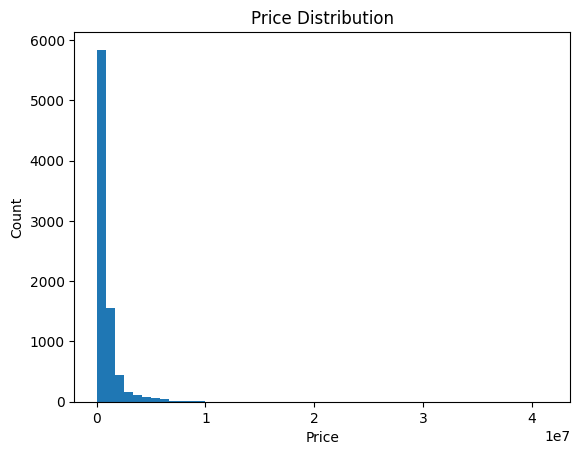

In [75]:
plt.hist(final_df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

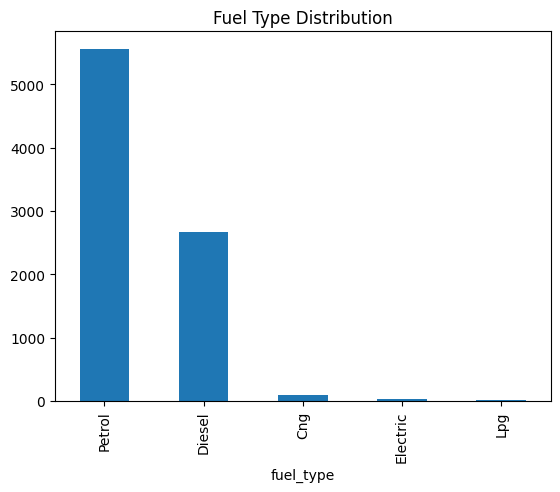

In [76]:
final_df["fuel_type"].value_counts().plot(kind="bar")
plt.title("Fuel Type Distribution")
plt.show()

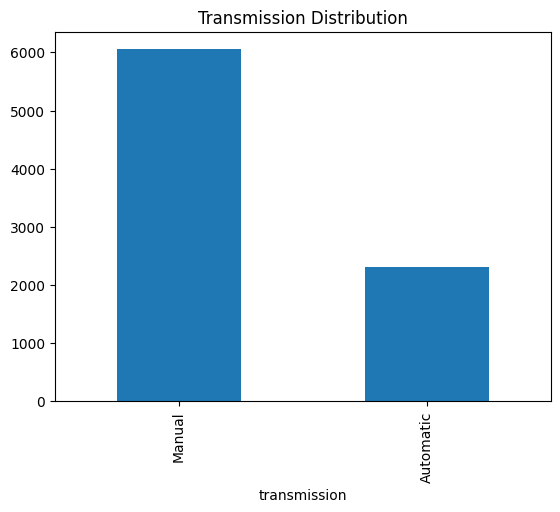

In [77]:
final_df["transmission"].value_counts().plot(kind="bar")
plt.title("Transmission Distribution")
plt.show()

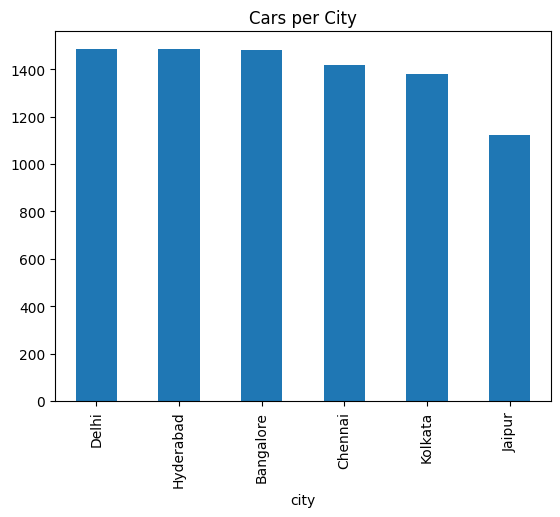

In [78]:
final_df["city"].value_counts().plot(kind="bar")
plt.title("Cars per City")
plt.show()

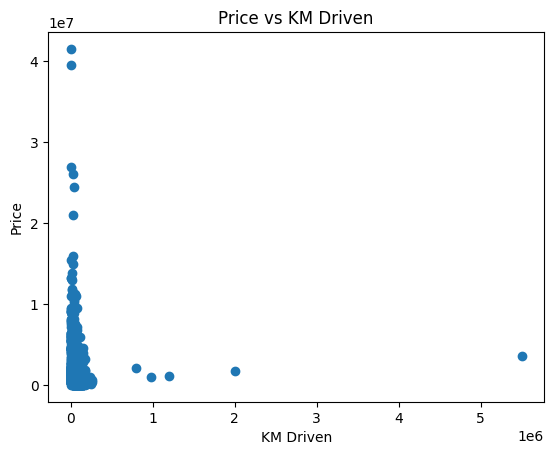

In [79]:
plt.scatter(final_df["km_driven"], final_df["price"])
plt.xlabel("KM Driven")
plt.ylabel("Price")
plt.title("Price vs KM Driven")
plt.show()

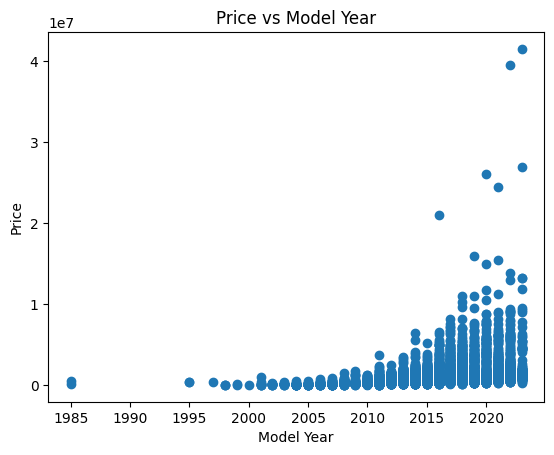

In [80]:
plt.scatter(final_df["model_year"], final_df["price"])
plt.xlabel("Model Year")
plt.ylabel("Price")
plt.title("Price vs Model Year")
plt.show()

In [81]:
import numpy as np

final_df["price_log"] = np.log1p(final_df["price"])

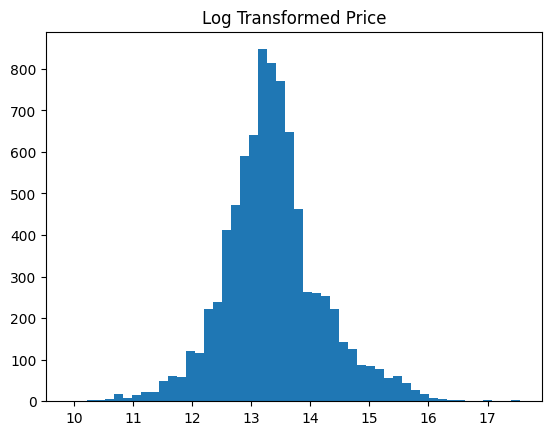

In [82]:
plt.hist(final_df["price_log"], bins=50)
plt.title("Log Transformed Price")
plt.show()

In [83]:
final_df = final_df.drop(columns=[
    "model",        # too many unique values
    "variant"       # too many unique values
])

In [84]:
final_df = pd.get_dummies(final_df, drop_first=True)

In [85]:
X = final_df.drop(columns=["price", "price_log"])
y = final_df["price_log"]

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.9216637513631675

In [89]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9216637513631675


In [90]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9376090097792181


In [91]:
import pickle

pickle.dump(rf, open("../output/model.pkl", "wb"))

In [92]:
final_df.to_csv("../output/final_cleaned_data.csv", index=False)

In [93]:
import pickle

pickle.dump(rf, open("../output/car_price_model.pkl", "wb"))

In [94]:
final_df.to_csv("../output/final_cleaned_data.csv", index=False)

In [95]:
import pickle

pickle.dump(rf, open("../output/car_price_model.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("../output/model_columns.pkl", "wb"))